## Multi-Armed Bandit as a Sequential Learning Problem

This notebook studies the multi-armed bandit problem as a sequential decision problem under uncertainty. At each date, an agent selects one action among several alternatives with unknown expected rewards. The central difficulty is that learning these rewards requires experimentation, while experimentation itself may reduce current performance.

---

### Appendix

1. [Presentation of the Multi-Armed Bandit Problem](#1.-presentation-of-the-multi-armed-bandit-problem)
2. [Pure Exploitation and Uniform Exploration](#2.-pure-exploitation-and-uniform-exploration)
3. [The Exploration-Exploitation Trade-off](#3.-the-exploration-exploitation-trade-off)
4. [A Simple Benchmark: Epsilon-Greedy](#4.-a-simple-benchmark:-epsilon-greedy)
5. [A Bayesian View of Learning: the Beta-Bernoulli Model](#5.-a-bayesian-view-of-learning:-the-beta-bernoulli-model)
6. [Naive Learning Strategy: Posterior Mean Greedy](#6.-naive-learning-strategy:-posterior-mean-greedy)
7. [Thompson Sampling](#7.-thompson-sampling)
8. [Toward Optimality: a Belief-Dependent Approach](#8.-toward-optimality:-a-belief-dependent-approach)
9. [Monte Carlo Comparison of Strategies](#9.-monte-carlo-comparison-of-strategies)
10. [Conclusion](#10.-conclusion)

<br>

---
### 1. Presentation of the Multi-Armed Bandit Problem

#### &nbsp;&nbsp; 1.1. Framework and objective

Consider a player facing $K$ slot machines. Each machine $i \in \{1, \dots, K\}$ pays out a reward drawn from an unknown distribution with mean $\mu_i$. At each time step $t$, the player selects one machine $A_t \in \{1, \dots, K\}$ and observes a reward $X_t$, where:

$$
X_t \sim \mathcal{D}_i \quad \text{and} \quad \mathbb{E}[X_t] = \mu_i
$$

The player does not observe the means $\mu_i$ directly — they must be inferred from past outcomes. We restrict attention to Bernoulli rewards. Each machine $i$ pays 1 with probability $\theta_i$ and 0 otherwise:

$$
X_{i,t} \sim \text{Bernoulli}(\theta_i), \quad \theta_i \in (0, 1)
$$

The vector $\theta_i = (\theta_1, ..., \theta_K)$ are fixed but unknown. The agent controls the sequence of actions $\{A_t\}_{t=1}^T$ and observes only the reward of the chosen arm at each step. The objective is to maximize cumulative reward:

$$
\max_{\{A_t\}} \quad W_T = \sum_{t=1}^{T} X_{A_t, t}
$$

#### &nbsp;&nbsp; 1.2. Oracle and Regret

In order to measure the performance of our strategy, we define a benchmark, which is the oracle strategy that always pulls the best arm, i.e., the arm with the highest expected value, denoted $\mu^*$. The cumulative regret measures the performance loss relative to this oracle:

$$
R_T = T \mu^* - \mathbb{E}[W_T]
$$

The difficulty does not come from optimization. It comes from the fact that learning requires action, and action has a cost. The agent faces a controlled stochastic process where:
- the **state** is the history of past actions and rewards $\mathcal{F}_t = \{A_s, X_s\}_{s < t}$,
- the **control** is the arm chosen at each step $A_t$,
- the **payoff** is $W_T$, which depends on both the quality of decisions and the information they generate.

The simulation below shows a setup where the agent starts by selecting one arm uniformly at random and commit to it for the rest of the game:

3


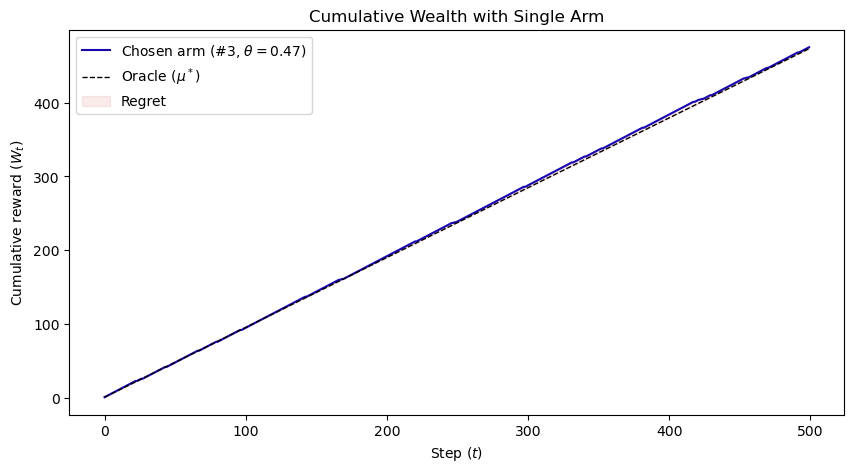

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
K = 3
T = 500
theta = np.random.random(K)

# Single arm strategy
def single_arm(K, theta, T):
    arm = np.random.randint(K)
    rewards = np.random.binomial(1, theta[arm], T)
    return K, np.cumsum(rewards)

# Oracle EV
def oracle_ev(theta, T):
    return np.arange(1, T + 1) * max(theta)

# Single Arm and Oracle
arm, W = single_arm(K, theta, T)
oracle = oracle_ev(theta, T)
print(arm)
# Plot
plt.figure(figsize=(10, 5))
plt.plot(W, linewidth=1.5, color="#1706B1", label=f"Chosen arm (#{arm}, $\\theta={round(theta[arm-1],2)}$)")
plt.plot(oracle, linewidth=1, linestyle="--", color="black", label="Oracle ($\\mu^*$)")
plt.fill_between(np.arange(T), W, oracle, alpha=0.08, color="#C20A0A", label="Regret")
plt.title(f"Cumulative Wealth with Single Arm")
plt.xlabel("Step ($t$)")
plt.ylabel("Cumulative reward ($W_t$)")
plt.legend()
plt.show()


The shaded area represents the regret accumulated by committing blindly to a single arm. If the chosen arm happens to be suboptimal — which occurs with probability $(K-1)/K$ — the gap grows linearly and never closes. This is the worst case of ignoring uncertainty entirely.

<br>

### 2. Pure Exploitation and Uniform Exploration

Before introducing any structured strategy, we examine two very simple ones. Both focus on a single choice, and ignore the tension between learning and optimizing — but in opposite directions.

#### &nbsp;&nbsp; 2.1. Pure Exploitation

A first natural and simple strategy is the following. The agent pulls each arm once to initialize, then permanently exploits the arm with the highest observed reward. Let $t=K$, $N_i(t)$ be the number of times the agent pulled the $i$-th machine, and $\hat{\mu}_i(t)$ the estimator of expected reward observed on the $i$-th machine. The agent act such that:

$$
A_t = \arg\max_{i} \hat{\mu}_i(t) \quad \text{and} \quad \hat{\mu}_i(t) = \frac{1}{N_i(t)} \sum_{s \leq t} X_{i,s} \cdot \mathbf{1}\{A_s = i\}
$$

After the initialization phase, the agent never updates its belief. This creates a path dependence problem: the arm selected depends entirely on the first $K$ observations, which are highly noisy. A single lucky draw from a suboptimal arm can lock the agent into a permanently suboptimal strategy.

#### &nbsp;&nbsp; 2.2. Uniform Exploration

A second simple situation is an agent that never commits. At each step, it selects an arm uniformly at random, regardless of past outcomes:

$$
A_t \sim \mathcal{U}\{1, \dots, K\}
$$

This agent learns, in the sense that it accumulates observations on all arms, but never uses what it learns to improve decisions. Asymptotically, it pulls each arm $T/K$ times, generating a cumulative reward of:

$$
\mathbb{E}[W_T] = T \cdot \frac{1}{K} \sum_{i=1}^K \theta_i
$$

This result is strictly less than $T \cdot \mu^*$ whenever arms are not identical. The regret grows linearly in $T$ and the uniform exploration strategy is asymptotically inefficient by construction.

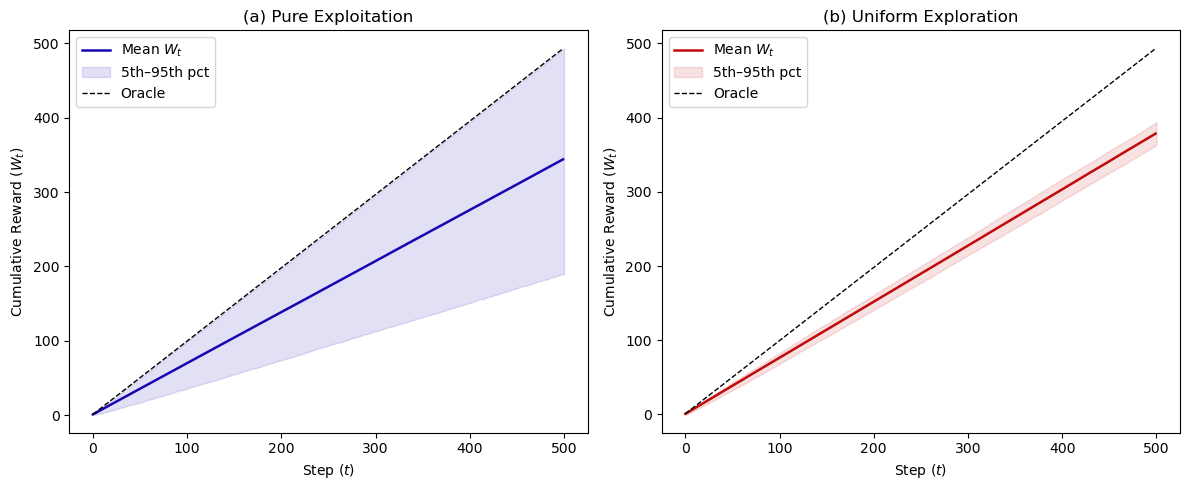

In [23]:
# Parameters
K = 3
T = 500
theta = np.random.random(K)
n_paths = 1000

# Oracle
oracle = np.arange(1, T + 1) * max(theta)

# Pure exploitation strategy
def pure_exploitation(T, K, theta):
    init_rewards = [np.random.binomial(1, theta[i]) for i in range(K)]
    chosen = np.argmax(init_rewards)
    rewards = [init_rewards[chosen]]
    for _ in range(T - 1):
        rewards.append(np.random.binomial(1, theta[chosen]))
    return np.cumsum(rewards)

# Uniform exploration
def uniform_exploration(T, K, theta):
    rewards = []
    for t in range(T):
        arm = np.random.randint(K)
        rewards.append(np.random.binomial(1, theta[arm]))
    return np.cumsum(rewards)

# Monte Carlo simulation
paths_exploit = np.array([pure_exploitation(T, K, theta) for _ in range(n_paths)])
paths_uniform = np.array([uniform_exploration(T, K, theta) for _ in range(n_paths)])

# Mean of the two process
mean_exploit = paths_exploit.mean(axis=0)
mean_uniform = paths_uniform.mean(axis=0)

# 90% range
p5_exploit,  p95_exploit  = np.percentile(paths_exploit, 5,  axis=0), np.percentile(paths_exploit, 95, axis=0)
p5_uniform,  p95_uniform  = np.percentile(paths_uniform, 5,  axis=0), np.percentile(paths_uniform, 95, axis=0)

# X axis
t_grid = np.arange(1, T + 1)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel (a)
axes[0].plot(mean_exploit, color="#1706B1", linewidth=1.8, label="Mean $W_t$")
axes[0].fill_between(t_grid, p5_exploit, p95_exploit, color="#1706B1", alpha=0.12, label="5th–95th pct")
axes[0].plot(oracle, color="black", linewidth=1, linestyle="--", label="Oracle")
axes[0].set_title("(a) Pure Exploitation")
axes[0].set_xlabel("Step ($t$)")
axes[0].set_ylabel("Cumulative Reward ($W_t$)")
axes[0].legend()

# Panel (b) 
axes[1].plot(mean_uniform, color="#C20A0A", linewidth=1.8, label="Mean $W_t$")
axes[1].fill_between(t_grid, p5_uniform, p95_uniform, color="#C20A0A", alpha=0.12, label="5th–95th pct")
axes[1].plot(oracle, color="black", linewidth=1, linestyle="--", label="Oracle")
axes[1].set_title("(b) Uniform Exploration")
axes[1].set_xlabel("Step ($t$)")
axes[1].set_ylabel("Cumulative Reward ($W_t$)")
axes[1].legend()

plt.tight_layout()
plt.show()

Panel A reveals the lock-in effect: the wide confidence band reflects path dependence: depending on which arm gets lucky in the first $K$ pulls, the agent may exploit one of the $K$ arms. If the arm is suboptimal, the strategy is too. Panel B shows less uncertainty but a lower mean: uniform exploration is stable but persistently suboptimal.

<br>

### 3. The Exploration–Exploitation Trade-off

The two strategies of the previous section fail for symmetric reasons: one acts without learning, the other learns without acting. The root cause is that both treat an action as having a single dimension — its immediate reward. In reality, every action has two components:

$$
\underbrace{X_{i,t}}_{\text{immediate reward}} \quad + \quad \underbrace{\mathcal{I}(A_t = i)}_{\text{informational value}}
$$

The immediate value of pulling arm $i$ is its expected reward $\theta_i$. The informational value is the reduction in uncertainty about $\theta_i$. An optimal agent should account for both.

#### &nbsp;&nbsp; 3.1. When Exploration is Rational

Consider this game with two arms. Arm 1 has been pulled many times and has a well-estimated mean. Arm 2 has been pulled rarely and carries high uncertainty. Even if arm 1 looks better on average, pulling arm 2 may reveal that it is the best arm, improving all future decisions.

This is the core of the trade-off. Since $\hat{\mu}_i(t)$ is a sample mean, the rationale behind exploration is to reduce the sample variance. The uncertainty of the agent estimate decreases with $N_i(t)$:

$$
\text{Var}[\hat{\mu}_i] = \frac{\theta_i(1-\theta_i)}{N_i(t)} = \frac{\hat{\mu}_i(1-\hat{\mu}_i)}{N_i(t)}
$$

An agent that ignores that always pulls the maximum value $\hat{\mu}_i(t)$ is blind: it optimizes today at the cost of potentially never identifying the true best arm.

#### &nbsp;&nbsp; 3.2. The Value of an Action

More formally, the value of pulling arm $i$ at step $t$ has two terms:

$$
V_t(i) = \underbrace{\hat{\mu}_i(t)}_{\text{exploit}} + \underbrace{\mathcal{I}\!\left(N_i(t), T-t\right)}_{\text{explore}}
$$

The value of exploration $\mathcal{I}$ increases when arm $i$ has been pulled few times and when the remaining horizon is long. It decreases as the agent accumulates observations or as $T - t$ shrinks. The tension is structural: the two terms pull in opposite directions.

The simulation below replicates this situation by comparaing the sampling distribution and mean of two arms. Arm 1 has been pulled many times, and Arm 2 has been pulled fewer times:

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2046: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2046: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


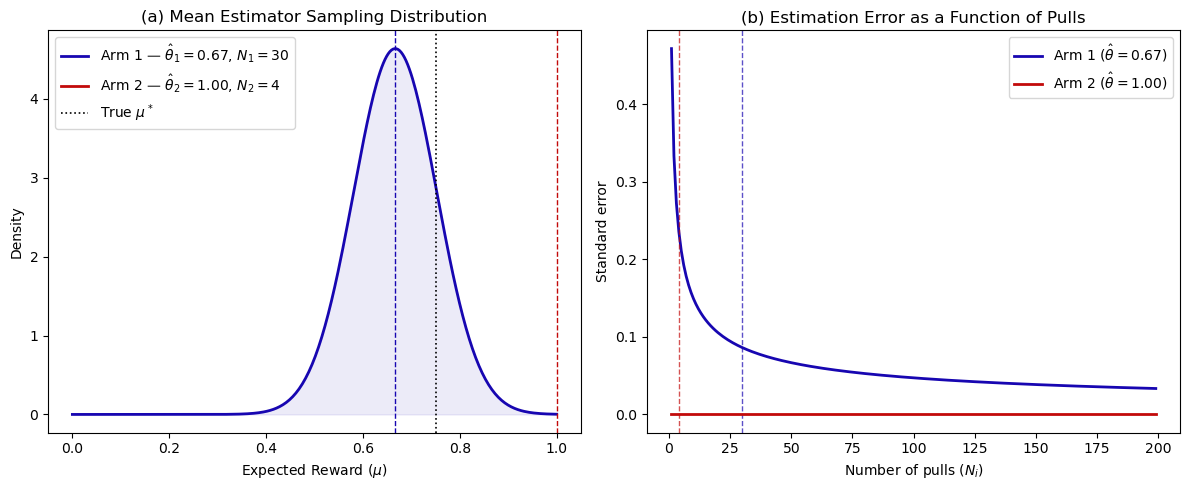

In [24]:
from scipy.stats import norm

# True parameters
theta = [0.6, 0.75]
K = 2

# Sample parameters
N = [30, 4]
obs = [np.random.binomial(1, theta[i], N[i]) for i in range(K)]
mu_hat = [o.mean() for o in obs]
se = [np.sqrt(m * (1 - m) / n) for m, n in zip(mu_hat, N)]

# Grid for sampling distribution
x = np.linspace(0, 1, 300)
colors = ["#1706B1", "#C20A0A"]
labels = [
    rf"Arm 1 — $\hat{{\theta}}_1={mu_hat[0]:.2f}$, $N_1={N[0]}$",
    rf"Arm 2 — $\hat{{\theta}}_2={mu_hat[1]:.2f}$, $N_2={N[1]}$",
]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A
for i in range(K):
    pdf = norm.pdf(x, mu_hat[i], se[i])
    axes[0].plot(x, pdf, color=colors[i], linewidth=2, label=labels[i])
    axes[0].fill_between(x, pdf, alpha=0.08, color=colors[i])
    axes[0].axvline(mu_hat[i], color=colors[i], linestyle="--", linewidth=1)

axes[0].axvline(max(theta), color="black", linestyle=":", linewidth=1.2, label=r"True $\mu^*$")
axes[0].set_title("(a) Mean Estimator Sampling Distribution")
axes[0].set_xlabel(r"Expected Reward ($\mu$)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Panel B
n_grid = np.arange(1, 200)
for i in range(K):
    variance = mu_hat[i] * (1 - mu_hat[i]) / n_grid
    axes[1].plot(n_grid, np.sqrt(variance), color=colors[i], linewidth=2,
                 label=rf"Arm {i+1} ($\hat{{\theta}}={mu_hat[i]:.2f}$)")
    axes[1].axvline(N[i], color=colors[i], linestyle="--", linewidth=1, alpha=0.7)

axes[1].set_title("(b) Estimation Error as a Function of Pulls")
axes[1].set_xlabel("Number of pulls ($N_i$)")
axes[1].set_ylabel("Standard error")
axes[1].legend()

plt.tight_layout()
plt.show()

Panel A shows the estimation distributions for both arms after $T$=34 pulls. Arm 1 appears empirically stronger — but its distribution is narrow, meaning little can be learned from pulling it again. Arm 2 has a wide distribution: its true value could be substantially higher than its current estimate. The informational value of pulling arm 2 is high.

Panel B shows how the informational value decays with the number of pulls. The dashed vertical lines mark the current position of each arm. Arm 2 sits far left on this curve — a few additional pulls would sharply reduce its uncertainty, potentially revealing it as the dominant arm.

<br>

### 4. A Simple Hybrid Strategy: Epsilon-Greedy

To address the issue of the two naive strategies discussed in the previous sections, we turn to a simple hybrid stratgey. It combines both mechanisms explicitly: explore with fixed probability $\varepsilon$, exploit the current maximum value $\mu_i$ otherwise.

$$
A_t = \begin{cases} A_t \sim \mathcal{U}\{1, \dots, K\} & \text{with p= } \varepsilon \\ \arg\max_i \hat{\mu}_i(t) & \text{with p= } 1-\varepsilon \end{cases}
$$

This rule guarantees that every arm is pulled infinitely often and that $\hat{\mu}_i(t) \to \theta_i$ for all $i$. It also concentrate most pulls on the empirically best arm. It escapes the lock-in of pure exploitation and the asymptotic inefficiency of uniform exploration.

The regret measure decomposes naturally. A fraction $\varepsilon$ of steps are wasted on random pulls and the remaining $1 - \varepsilon$ fraction exploit the current best estimate, with regret that shrinks as estimates improve:

$$
R_T \approx \varepsilon \cdot T \cdot \left(\mu^* - \frac{1}{K}\sum_i \theta_i\right) + (1-\varepsilon) \cdot \sum_i (\mu^* - \mu_i) \cdot \mathbb{E}[N_i(T)]
$$

The first term dominates asymptotically — epsilon-greedy still accumulates linear regret in $T$, because it keeps exploring at rate $\varepsilon$ even after the best arm is identified with high confidence. This is its fundamental limitation: exploration is blind and never phases out.

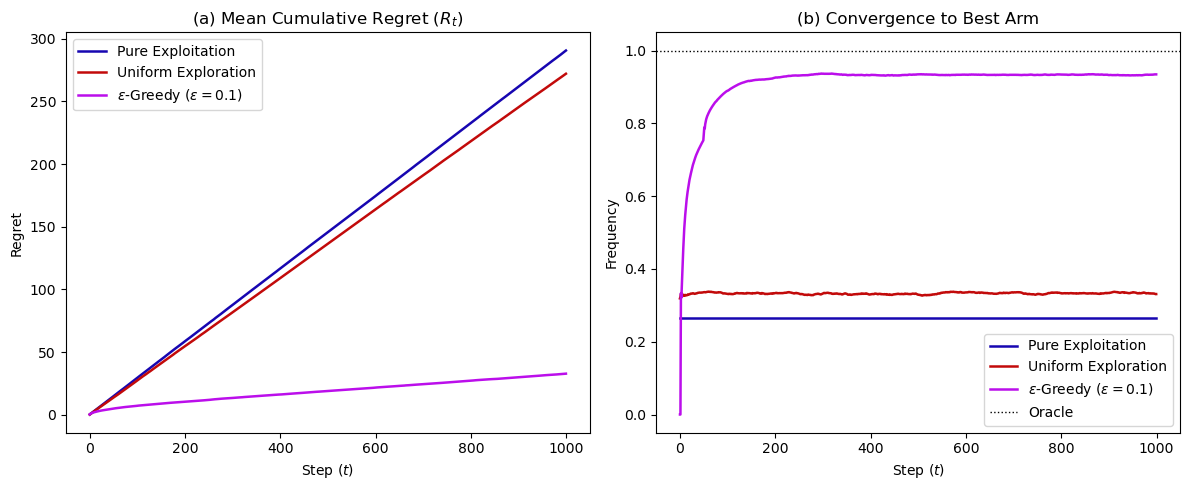

In [25]:

# Params
K = 3
T = 1000
theta = np.random.random(3)
n_paths = 1000
epsilon = 0.1
mu_star = max(theta)
best_arm = np.argmax(theta)

# --- Strategies ---
def pure_exploitation2(T, K, theta):
    init_rewards = [np.random.binomial(1, theta[i]) for i in range(K)]
    arm = np.argmax(init_rewards)
    rewards = np.random.binomial(1, theta[arm], T)
    return rewards, np.full(T, arm)

def uniform_exploration2(T, K, theta):
    chosen = np.random.randint(K, size=T)
    rewards = np.array([np.random.binomial(1, theta[c]) for c in chosen])
    return rewards, chosen

def epsilon_greedy(T, K, theta, epsilon=0.1):
    mu_hat = np.zeros(K)
    N = np.zeros(K)
    rewards, chosen = [], []
    for i in range(K):
        r = np.random.binomial(1, theta[i])
        mu_hat[i] = r
        N[i] = 1
        rewards.append(r)
        chosen.append(i)
    for _ in range(T - K):
        arm = np.random.randint(K) if np.random.rand() < epsilon else np.argmax(mu_hat)
        r = np.random.binomial(1, theta[arm])
        N[arm] += 1
        mu_hat[arm] += (r - mu_hat[arm]) / N[arm]
        rewards.append(r)
        chosen.append(arm)
    return np.array(rewards), np.array(chosen)

# Monte Carlo
def monte_carlo(strategy, n_paths, *args):
    all_rewards, all_chosen = [], []
    for _ in range(n_paths):
        r, c = strategy(*args)
        all_rewards.append(r)
        all_chosen.append(c)
    return np.array(all_rewards), np.array(all_chosen)

rw_exp,  ch_exp  = monte_carlo(pure_exploitation2, n_paths, T, K, theta)
rw_uni,  ch_uni  = monte_carlo(uniform_exploration2, n_paths, T, K, theta)
rw_eps,  ch_eps  = monte_carlo(epsilon_greedy, n_paths, T, K, theta, epsilon)

# Regret
t_len = rw_eps.shape[1]
t_grid = np.arange(1, t_len + 1)
regret_exp = t_grid * mu_star - rw_exp[:, :t_len].cumsum(axis=1).mean(axis=0)
regret_uni = t_grid * mu_star - rw_uni[:, :t_len].cumsum(axis=1).mean(axis=0)
regret_eps = t_grid * mu_star - rw_eps[:, :t_len].cumsum(axis=1).mean(axis=0)

# Best arm frequency
window = 50
def best_arm_freq(chosen, best_arm, window):
    is_best = (chosen == best_arm).astype(float)
    return np.array([is_best[:, max(0, t-window):t].mean(axis=1).mean() for t in range(1, is_best.shape[1]+1)])

freq_exp = best_arm_freq(ch_exp, best_arm, window)
freq_uni = best_arm_freq(ch_uni, best_arm, window)
freq_eps = best_arm_freq(ch_eps, best_arm, window)

# Plot
colors = {"exploit": "#1706B1", "uniform": "#C20A0A", "eps": "#bb0eeb"}
labels = {"exploit": "Pure Exploitation", "uniform": "Uniform Exploration", "eps": f"$\\varepsilon$-Greedy ($\\varepsilon={epsilon}$)"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A
axes[0].plot(regret_exp, color=colors["exploit"], linewidth=1.8, label=labels["exploit"])
axes[0].plot(regret_uni, color=colors["uniform"], linewidth=1.8, label=labels["uniform"])
axes[0].plot(regret_eps, color=colors["eps"],     linewidth=1.8, label=labels["eps"])
axes[0].set_title("(a) Mean Cumulative Regret ($R_t$)")
axes[0].set_xlabel("Step ($t$)")
axes[0].set_ylabel("Regret")
axes[0].legend()

# Panel B
axes[1].plot(freq_exp, color=colors["exploit"], linewidth=1.8, label=labels["exploit"])
axes[1].plot(freq_uni, color=colors["uniform"], linewidth=1.8, label=labels["uniform"])
axes[1].plot(freq_eps, color=colors["eps"],     linewidth=1.8, label=labels["eps"])
axes[1].axhline(1.0, color="black", linestyle=":", linewidth=1, label="Oracle")
axes[1].set_title("(b) Convergence to Best Arm")
axes[1].set_xlabel("Step ($t$)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()


Panel A confirms that epsilon-greedy strategy accumulates regret strictly slower than both extremes early on. However, its slope never reaches zero, reflecting the permanent exploration cost. Panel (b) shows that it converges to selecting the best arm far more reliably than uniform exploration.

<br>

### 5. A Bayesian View of Learning: the Beta-Bernoulli Model

So far, the agent summarizes its knowledge of arm $i$ by a single number $\hat{\mu}_i(t)$. This representation discards how uncertain that estimate is. The Bayesian approach replaces the point estimate with a full distribution over $\mu_i$, denoted $p$. Instead of asking what is the best guess for $\mu_i$, the agent maintains a belief:

$$
p(\mu_i \mid \mathcal{F}_t)
$$

This prior distribution is updated after every observation via Bayes' theorem, yielding the posterior distributionn:

$$
 p(\mu_i​\mid\mathcal{F}_t​)=  p(\mu_i​\mid X_t , \mathcal{F}_{t-1}​) = \frac{p(X_t​ \mid \mu_i​, \mathcal{F}_{t-1})⋅p(\mu_i \mid \mathcal{F}_{t-1})​}{p(X_t \mid \mathcal{F}_{t-1}​)} = \frac{p(X_t​ \mid \mu_i)⋅p(\mu_i \mid \mathcal{F}_{t-1})​}{p(X_t \mid \mathcal{F}_{t-1}​)}
$$

The terms of the posterior belief conditionned to the full set of information have a natural interpretation:
- $p(\mu_i \mid \mathcal{F}_{t-1})$ — this is the prior belief for $\mu_i$ before observing $X_t$,
- $ p(X_t \mid \mu_i)$ — likelihood of observing $X_t$ coniditional on our prior belief for $\mu_i$,
- $p(\mu_i \mid \mathcal{F}_t)$ — posterior belief of $\mu_i$ after observing $X_t$, where $\mathcal{F}_t = \mathcal{F}_{t-1} \cup \{A_t, X_t\}$

#### &nbsp;&nbsp; 5.1. The Beta-Bernoulli Model

We now define the distribution of the agent belief. The natural prior is a $\text{Beta}(\alpha_i, \beta_i)$ distribution, defined on $(0,1)$, with density:

$$
p(\mu_i) = \frac{\mu_i^{\alpha_i - 1}(1-\mu_i)^{\beta_i - 1}}{B(\alpha_i, \beta_i)} \; \sim \; \text{Beta}(\alpha_i, \beta_i)
$$

The parameters $\alpha_i$ and $\beta_i$ have a direct interpretation: $\alpha_i$ counts the number of observed successes, $\beta_i$ the number of observed failures. We initialize with $\alpha_i = \beta_i = 1$, which corresponds to a uniform prior over $(0,1)$ — expressing ignorance about $\mu_i$.

#### &nbsp;&nbsp; 5.2. Posterior Update

The Beta distribution is the conjugate prior for the Bernoulli likelihood. This means the posterior after observing $X_t \in \{0,1\}$ remains in the Beta family, with a closed-form update:

$$
\mu_i \mid \mathcal{F}_t \sim \text{Beta}(\alpha_i + S_i(t),\; \beta_i + N_i(t) - S_i(t))
$$

where $S_i(t)$ is the number of successes observed on arm $i$. The update rule is immediate: a success increments $\alpha_i$, a failure increments $\beta_i$. The posterior mean and variance are:

$$
\mathbb{E}[\mu_i \mid \mathcal{F}_t] = \frac{\alpha_i}{\alpha_i + \beta_i} \qquad \text{and} \qquad \text{Var}[\mu_i \mid \mathcal{F}_t] = \frac{\alpha_i \beta_i}{(\alpha_i + \beta_i)^2(\alpha_i + \beta_i + 1)}
$$

As $N_i(t) \to \infty$, the variance collapses to zero and the posterior mean converges to $\mu_i$ — the agent learns the true parameter exactly.


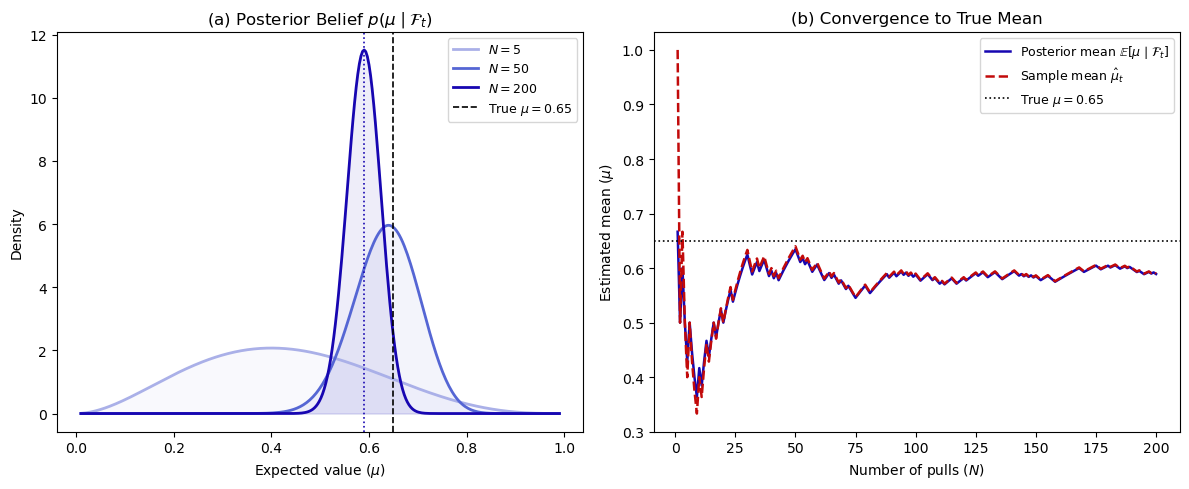

In [26]:
from scipy.stats import beta as beta_dist

# Params
theta, T = 0.65, 200
snapshots = [5, 50, 200]
snap_colors = ["#aab0e8", "#5566d4", "#1706B1"]

# Sequential observations
obs = np.random.binomial(1, theta, T)
alphas = 1 + np.cumsum(obs)
betas_  = 1 + np.cumsum(1 - obs)
post_mean   = alphas / (alphas + betas_)
sample_mean = np.cumsum(obs) / np.arange(1, T + 1)

# X axis
x = np.linspace(0.01, 0.99, 300)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A
for N, col in zip(snapshots, snap_colors):
    a, b = alphas[N-1], betas_[N-1]
    pdf = beta_dist.pdf(x, a, b)
    axes[0].plot(x, pdf, color=col, linewidth=2, label=rf"$N={N}$")
    axes[0].fill_between(x, pdf, alpha=0.07, color=col)

axes[0].axvline(theta, color="black", linestyle="--", linewidth=1.2, label=rf"True $\mu={theta}$")
axes[0].axvline(post_mean[-1], color="#1706B1", linestyle=":", linewidth=1.2)
axes[0].set_title(r"(a) Posterior Belief $p(\mu \mid \mathcal{F}_t)$")
axes[0].set_xlabel(r"Expected value ($\mu$)")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=9)

# Panel B
n_grid = np.arange(1, T + 1)
axes[1].plot(n_grid, post_mean,   color="#1706B1", linewidth=1.8, label=r"Posterior mean $\mathbb{E}[\mu \mid \mathcal{F}_t]$")
axes[1].plot(n_grid, sample_mean, color="#C20A0A", linewidth=1.8, linestyle="--", label=r"Sample mean $\hat{\mu}_t$")
axes[1].axhline(theta, color="black", linestyle=":", linewidth=1.2, label=rf"True $\mu={theta}$")
axes[1].set_title("(b) Convergence to True Mean")
axes[1].set_xlabel("Number of pulls ($N$)")
axes[1].set_ylabel(r"Estimated mean ($\mu$)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

Panel A shows the posterior belief $p(\mu \mid \mathcal{F}_t)$ at three snapshots. As pulls accumulate, the distribution concentrates sharply around the true value: the agent is learning. Panel B confirms that both the posterior mean and the sample mean converge to $\mu$, but the posterior mean is more stable early on. It avoids the extreme estimates that the sample mean produces with few observations.


### 6. Naive Learning Strategy: Posterior Mean Greedy

The Bayesian framework of the previous section gives the agent a full distribution over each $\mu_i$. The simplest way to turn this into a decision rule is to pick the arm with the highest posterior mean:

$$
A_t = \arg\max_{i} \; \mathbb{E}[\mu_i \mid \mathcal{F}_{t-1}] = \arg\max_{i} \; \frac{\alpha_i}{\alpha_i + \beta_i}
$$

This is the posterior mean greedy strategy. It improves over the epsilon-greedy strategt in one important way: the posterior mean is regularized by the prior, so it never collapses with few observations. Early estimates are more stable, and the agent exploit efficiently.

However, the strategy remains fundamentally myopic. At each step, it maximizes the expected reward under the current belief — ignoring entirely what the chosen action will reveal about the true $\mu_i$. The posterior mean is a sufficient statistic for exploitation. It is not a sufficient statistic for decision-making under uncertainty.

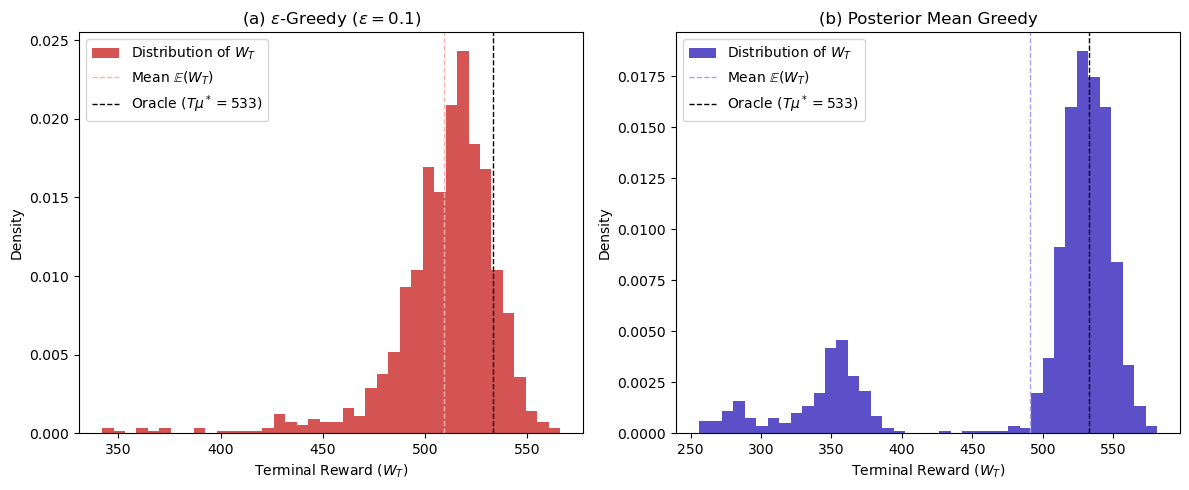

In [37]:
# Params
K = 3
T = 1000
theta = np.random.random(K)
n_paths = 1000
mu_star = max(theta)
best_arm = np.argmax(theta)

# Posterior MG strategy
def posterior_mean_greedy(T, K, theta):
    alpha = np.ones(K)
    beta  = np.ones(K)
    rewards, chosen = [], []
    for _ in range(T):
        arm = np.argmax(alpha / (alpha + beta))
        r = np.random.binomial(1, theta[arm])
        if r == 1:
            alpha[arm] += 1
        else:
            beta[arm] += 1
        rewards.append(r)
        chosen.append(arm)
    return np.array(rewards), np.array(chosen)

# MC Simulation
rw_eps, ch_eps = monte_carlo(epsilon_greedy, n_paths, T, K, theta, 0.1)
rw_pmg, ch_pmg = monte_carlo(posterior_mean_greedy, n_paths, T, K, theta)

# Terminal W
wT_eps = rw_eps.cumsum(axis=1)[:, -1]
wT_pmg = rw_pmg.cumsum(axis=1)[:, -1]
oracle_wT = T * mu_star

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A
axes[0].hist(wT_eps, bins=40, color="#C20A0A", alpha=0.7, density=True, label=r"Distribution of $W_T$")
axes[0].axvline(wT_eps.mean(), color="#FFB0B0", linewidth=1, linestyle="--", label=r"Mean $\mathbb{E}(W_T)$")
axes[0].axvline(oracle_wT, color="black", linewidth=1, linestyle="--", label=rf"Oracle ($T\mu^*={oracle_wT:.0f}$)")
axes[0].set_title(r"(a) $\varepsilon$-Greedy ($\varepsilon=0.1$)")
axes[0].set_xlabel("Terminal Reward ($W_T$)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Panel B
axes[1].hist(wT_pmg, bins=40, color="#1706B1", alpha=0.7, density=True, label=r"Distribution of $W_T$")
axes[1].axvline(wT_pmg.mean(), color="#A9A1F3", linewidth=1, linestyle="--", label=r"Mean $\mathbb{E}(W_T)$")
axes[1].axvline(oracle_wT, color="black", linewidth=1, linestyle="--", label=rf"Oracle ($T\mu^*={oracle_wT:.0f}$)")
axes[1].set_title("(b) Posterior Mean Greedy")
axes[1].set_xlabel("Terminal Reward ($W_T$)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()


Panel A shows a unimodal distribution for $\varepsilon$-greedy: forced exploration prevents lock-in, so outcomes are consistent across paths but systematically below the oracle due to the permanent exploration cost. Panel B reveals a bimodal distribution for posterior mean greedy: a large mass near the oracle corresponds to paths that locked in on the best arm early, while a lower-reward mass reflects paths that committed to a suboptimal arm and never recovered.

The bimodality is the signature of the lock-in mechanism — posterior mean greedy is a high-variance strategy. Its mean performance can match or exceed $\varepsilon$-greedy, but it achieves this through a mixture of very good and very bad outcomes, rather than consistent near-optimal behavior.

<br>

### 7. Bayesian Learning: Thompson Sampling Strategy

Posterior mean greedy summarizes the posterior distribution by a single number — its mean. In doing so, it discards the uncertainty around that mean. We introduce Thompson Sampling, which uses the full posterior distribution as a decision rule.

#### &nbsp;&nbsp; 7.1. The Decision Rule

Thompson sampling address the issue faced by the post mean greedy through a very simple process. Instead of selecting the highest expected value among arms, the agent draws one realization for each arm $i$ from its current belief distribution. Let $\mu$ be the drawn vector for machine $i$ to $K$:

$$
\tilde{\mu} = (\tilde{\mu_1}, \tilde{\mu_2}, ..., \tilde{\mu}_K) \; \sim \; \text{Beta}(\alpha_i, \beta_i)
$$

Note that $\tilde{\mu}_i$ is a plausible value of $\mu_i$ given everything the agent has observed so far. It is not an estimate; it is a draw from the agent's current belief about what $\mu_i$ could be. Then, the agent pull the arm with the highest sampled value:

$$
A_t = \arg\max_{i} \; \tilde{\mu}_i
$$

Finally, the agent pulls the arm and observes a realization $X_t$. He then updates the arm posterior distribution following the routine detailed in previous sections:

$$
\mu_i \mid \mathcal{F}_{t-1} \; \sim \; \text{Beta}(\alpha_{A_t} + X_t,\; \beta_{A_t} + 1 - X_t)
$$

#### &nbsp;&nbsp; 7.2. Why Exploration Emerges Naturally

Consider two arms after $t$ steps. Arm 1 has been pulled 100 times — its posterior is narrow and concentrated around $\mu_1$. Arm 2 has been pulled 5 times — its posterior is wide, and $\tilde{\mu}_2$ can take values across a large range. When the agent samples $\tilde{\mu}_2$ from a wide distribution, there is a non-trivial probability that the draw lands above $\tilde{\mu}_1$, even if the posterior mean of arm 2 is currently lower. This gives arm 2 a natural chance of being selected and explored further.

This mechanism has a precise interpretation. The agent selects arm $i$ when its sample $\tilde{\mu}_i$ is the highest across all arms. Since each $\tilde{\mu}_i$ is drawn from the posterior $p(\mu_i \mid \mathcal{F}_{t-1})$, the probability of selecting arm $i$ is exactly the probability that a draw from its posterior exceeds all other draws:

$$
\mathbb{P}(A_t = i \mid \mathcal{F}_{t-1}) = \mathbb{P}\!\left(\tilde{\mu}_i > \tilde{\mu}_j \; \forall j \neq i \;\middle|\; \mathcal{F}_{t-1}\right)
$$

Since $\tilde{\mu}_i \sim p(\mu_i \mid \mathcal{F}_{t-1})$ is a sample from what the agent believes $\mu_i$ could be, this probability is exactly the posterior probability that arm $i$ is the best arm:

$$
\mathbb{P}(A_t = i \mid \mathcal{F}_{t-1}) = \mathbb{P}\!\left(\mu_i = \max_{j} \mu_j \;\middle|\; \mathcal{F}_{t-1}\right)
$$

An arm is explored precisely as often as the agent believes it could be optimal. A well-identified suboptimal arm has near-zero probability of producing a high sample, so it is almost never selected. A poorly identified arm retains a probability of being optimal, so it continues to be explored until that uncertainty resolves.

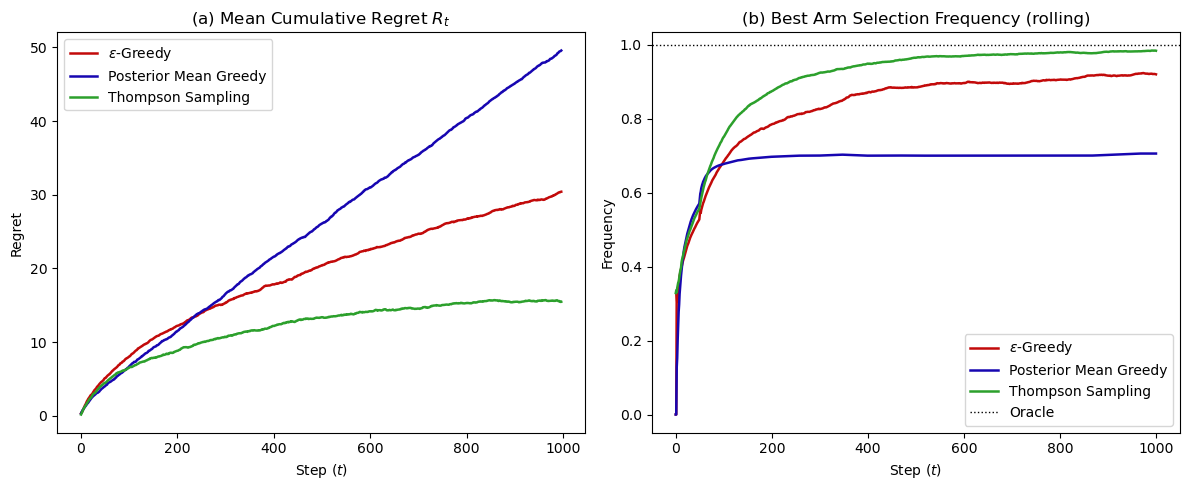

In [28]:
# Params
K = 3
T = 1000
theta = np.random.random(K)
n_paths = 350
mu_star = max(theta)
best_arm = np.argmax(theta)

# Thompson Sampling
def thompson_sampling(T, K, theta):
    alpha = np.ones(K)
    beta  = np.ones(K)
    rewards, chosen = [], []
    for _ in range(T):
        samples = np.random.beta(alpha, beta)
        arm = np.argmax(samples)
        r = np.random.binomial(1, theta[arm])
        if r == 1:
            alpha[arm] += 1
        else:
            beta[arm] += 1
        rewards.append(r)
        chosen.append(arm)
    return np.array(rewards), np.array(chosen)

# Monte Carlo
rw_eps, ch_eps = monte_carlo(epsilon_greedy,        n_paths, T, K, theta)
rw_pmg, ch_pmg = monte_carlo(posterior_mean_greedy, n_paths, T, K, theta)
rw_ts,  ch_ts  = monte_carlo(thompson_sampling,     n_paths, T, K, theta)

# X Axis
t_len = T - K
t_grid = np.arange(1, t_len + 1)

# Regret
def regret(rw, mu_star, t_len):
    return np.arange(1, t_len + 1) * mu_star - rw[:, :t_len].cumsum(axis=1).mean(axis=0)
reg_eps = regret(rw_eps, mu_star, t_len)
reg_pmg = regret(rw_pmg, mu_star, t_len)
reg_ts  = regret(rw_ts,  mu_star, t_len)

# Best arm frequency
window = 50
freq_eps = best_arm_freq(ch_eps, best_arm, window)
freq_pmg = best_arm_freq(ch_pmg, best_arm, window)
freq_ts  = best_arm_freq(ch_ts,  best_arm, window)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {"eps": "#C20A0A", "pmg": "#1706B1", "ts": "#2ca02c"}
labels = {"eps": r"$\varepsilon$-Greedy", "pmg": "Posterior Mean Greedy", "ts": "Thompson Sampling"}

# Panel A
for key in ["eps", "pmg", "ts"]:
    axes[0].plot({"eps": reg_eps, "pmg": reg_pmg, "ts": reg_ts}[key],
                 color=colors[key], linewidth=1.8, label=labels[key])
axes[0].set_title("(a) Mean Cumulative Regret $R_t$")
axes[0].set_xlabel("Step ($t$)")
axes[0].set_ylabel("Regret")
axes[0].legend()

# Panel B
for key in ["eps", "pmg", "ts"]:
    axes[1].plot({"eps": freq_eps, "pmg": freq_pmg, "ts": freq_ts}[key],
                 color=colors[key], linewidth=1.8, label=labels[key])
axes[1].axhline(1.0,  color="black", linestyle=":",  linewidth=1, label="Oracle")
axes[1].set_title("(b) Best Arm Selection Frequency (rolling)")
axes[1].set_xlabel("Step ($t$)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

Panel A shows that Thompson Sampling accumulates regret at a strictly slower rate than both benchmarks — the slope of $R_t$ decreases over time, reflecting the sublinear regret property. Panel B shows that it converges to selecting the best arm more rapidly, with fewer suboptimal pulls.

The key insight is that Thompson Sampling never explicitly trades off exploration and exploitation. It simply samples from what it believes, and acts on that sample. As beliefs sharpen, behavior naturally shifts from exploration to exploitation.

<br>

### 8. Toward Optimality: A Belief-State Approach

All previous strategies are relatively blind: at each step, they act on what they know now without explicitly accounting for what their action will reveal. Thompson Sampling comes close to optimal, but never looks ahead. We now turn to an optimal strategy that does both.

#### &nbsp;&nbsp; 8.1. The Optimal Control Problem

The fundamental information set of the bandit problem is not $\mu_i$ or $\mathcal{F}_t$, it is the agent's full belief over each arm at each time step:

$$
b_t = \left\{ \mu_i \mid \mathcal{F}_t \sim \text{Beta}(\alpha_i, \beta_i) \right\}_{i=1}^K
$$

This belief state encodes everything the agent knows at time $t$. Pulling arm $i$ and observing $X_t$ transitions the belief state deterministically. Then, the bandit is a dynamic control problem over the space of beliefs. We define an optimal value function $V(b_t, \tau)$, which is the maximum expected reward from belief state $b_t$ with $\tau$ steps remaining. It satisfies the Bellman equation:

$$
V(b, \tau) = \max_{i} \left[ \; \underbrace{\frac{\alpha_i}{\alpha_i + \beta_i}}_{\text{exploitation}} + \underbrace{\mathbb{E}_{X}\!\left[ V(b^{(i,X)},\, \tau - 1) \right]}_{\text{informational value}} \; \right]
$$

The first term is the immediate expected reward from arm $i$. The second term is the expected future value after the belief update, it captures how much pulling arm $i$ improves all subsequent decisions. The optimal policy pulls the arm that maximizes their sum:

$$
A_t^* = \arg\max_{i} \left[ \frac{\alpha_i}{\alpha_i + \beta_i} + \mathbb{E}_{X}\!\left[ V(b^{(i,X)},\, \tau - 1) \right] \right]
$$

This is the first strategy that explicitly values future information.

#### &nbsp;&nbsp; 8.2. Intractability and Thompson Sampling

Solving the Bellman equation requires evaluating $V(b, \tau)$ for every reachable belief state. At each step, each arm pull branches into two possible outcomes, $X = 0$ or $X = 1$, producing two new belief states. Over $\tau$ steps and $K$ arms, the number of belief states to evaluate grows as:

$$
\mathcal{O}\!\left(2^{K\tau}\right)
$$

The belief state space is also continuous: $(\alpha_i, \beta_i)$ take any positive integer values, so there is no finite grid to compute over. Thus, the computation of the optimal arm is only feasible for $K = 2$ and short horizons.

For that reason, it makes sense to use Thompson Sampling as an approximation for the Bellman methodology. In fact, this strategy implicitly approximates the informational value term: an uncertain arm has a higher probability of producing a large sample, acting as a proxy for high future value.

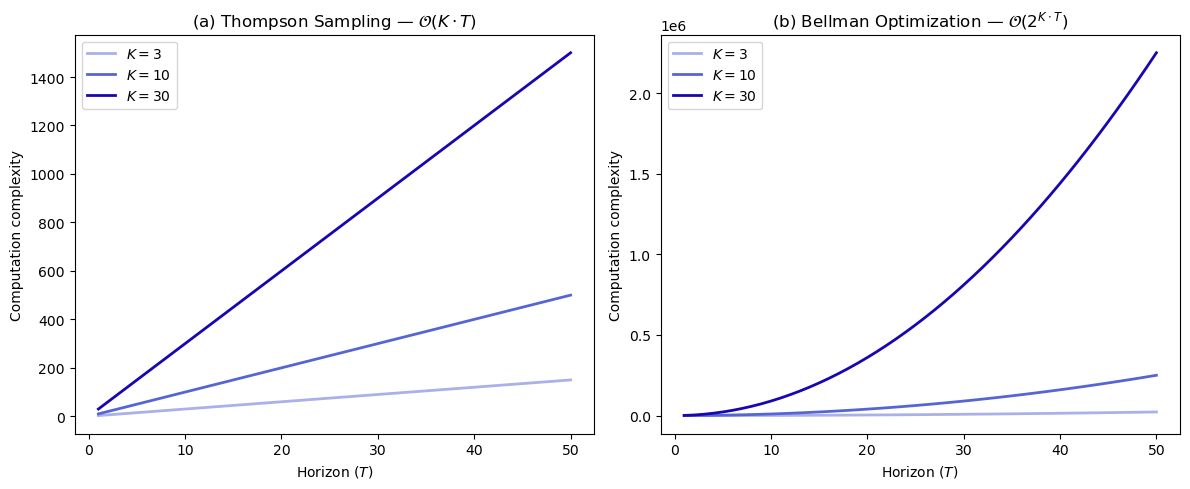

In [29]:
# Horizon and number of arms
T_grid = np.arange(1, 51)
K_values = [3, 10, 30]
colors = ["#aab0e8", "#5566d4", "#1706B1"]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A
for K, col in zip(K_values, colors):
    complexity = K * T_grid
    axes[0].plot(T_grid, complexity, color=col, linewidth=2, label=f"$K={K}$")

axes[0].set_title("(a) Thompson Sampling — $\\mathcal{O}(K \\cdot T)$")
axes[0].set_xlabel("Horizon ($T$)")
axes[0].set_ylabel("Computation complexity")
axes[0].legend()

# Panel B
for K, col in zip(K_values, colors):
    # Cap exponent to avoid overflow
    exponent = K * T_grid
    log_complexity = exponent ** 2
    axes[1].plot(T_grid, log_complexity, color=col, linewidth=2, label=f"$K={K}$")

axes[1].set_title("(b) Bellman Optimization — $\\mathcal{O}(2^{K \\cdot T})$")
axes[1].set_xlabel("Horizon ($T$)")
axes[1].set_ylabel("Computation complexity")
axes[1].legend()

plt.tight_layout()
plt.show()

The graph above shows that Thompson Sampling scales linearly. On the other hand, Bellman solution grows exponentially in both $K$ and $T$ — already for $K=3$, the complexity reaches astronomical values within a few dozen steps. For $K=10$ or $K=50$, the problem becomes intractable almost immediately. Thompson Sampling is the only optimal and tractable strategy.

<br>

### 9. Monte Carlo Comparison of Strategies

We now systematically compare the three structured strategies studied — $\varepsilon$-Greedy, Posterior Mean Greedy, and Thompson Sampling — across four scenarios. Each scenario isolates a specific difficulty of the multi-armed bandit problem.

Rather than tracking cumulative reward $W_t$ directly, we measure the fraction of the oracle reward captured at each step:

$$
\lambda_t = \frac{W_t}{t \cdot \mu^*} \in [0, 1]
$$

This normalization makes strategies comparable across scenarios, and gives an immediate reading: a value of 0.9 at step $t$ means the agent has captured 90% of what the best possible strategy would have earned. It also shows the learning capacity of each strategy.

#### &nbsp;&nbsp; 9.1. Easy Setting

This scenario presents three arms with well-separated reward probabilities $\theta = [0.2, 0.5, 0.8]$. The gap between the best arm and the others is large: even noisy early estimates are sufficient to identify the dominant arm quickly.

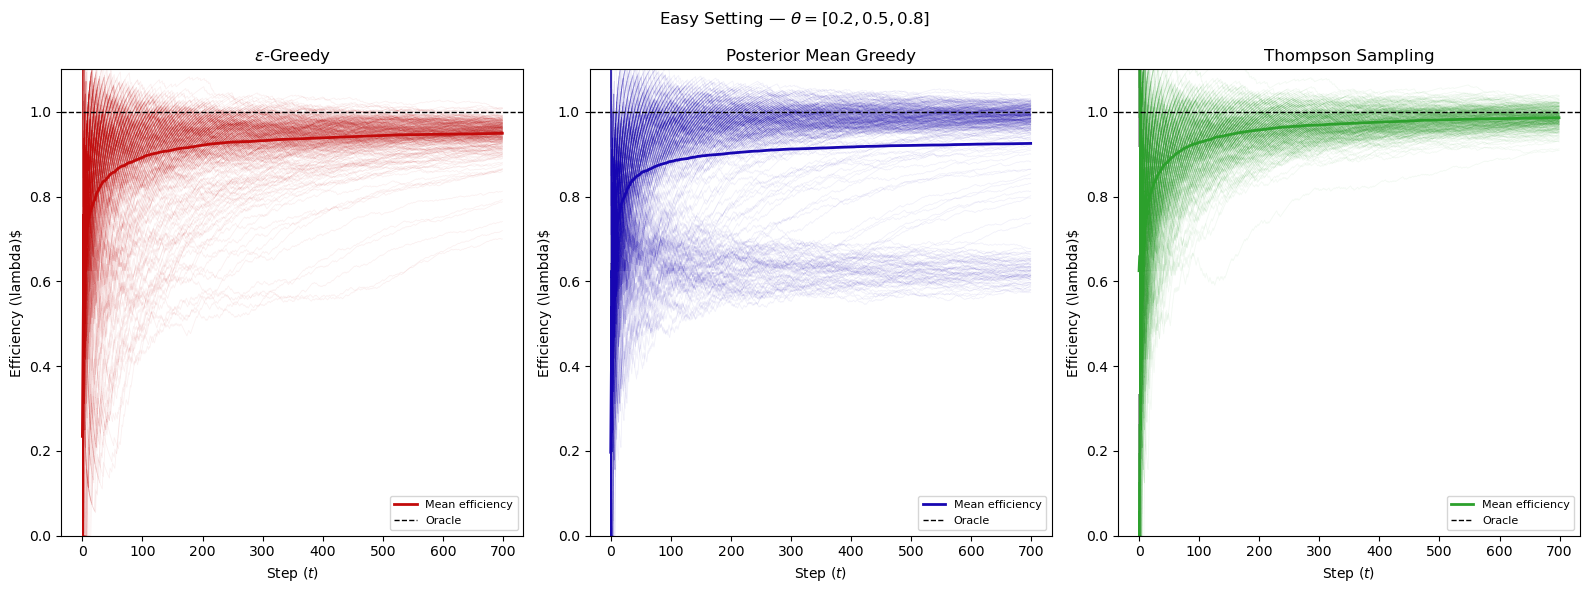

In [30]:
# Params
T, n_paths = 700, 400
theta = [0.2, 0.5, 0.8]
K = len(theta)

# Oracle
mu_star = max(theta)
oracle = np.arange(1, T + 1) * mu_star

# MC Simulation
rw_eps, _ = monte_carlo(epsilon_greedy, n_paths, T, K, theta)
rw_pmg, _ = monte_carlo(posterior_mean_greedy, n_paths, T, K, theta)
rw_ts, _ = monte_carlo(thompson_sampling, n_paths, T, K, theta)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
colors = ["#C20A0A", "#1706B1", "#2ca02c"]
strategies = [r"$\varepsilon$-Greedy", "Posterior Mean Greedy", "Thompson Sampling"]

for ax, rw, color, label in zip(axes, [rw_eps, rw_pmg, rw_ts], colors, strategies):
    cum = rw.cumsum(axis=1)
    eff = cum / oracle

    for path in eff:
        ax.plot(path, alpha=0.06, linewidth=0.6, color=color)
    ax.plot(eff.mean(axis=0), color=color, linewidth=2, label="Mean efficiency")
    ax.axhline(1.0, color="black", linewidth=1, linestyle="--", label="Oracle")
    ax.set_ylim(0, 1.1)
    ax.set_title(label)
    ax.set_xlabel("Step ($t$)")
    ax.set_ylabel(r"Efficiency (\lambda)$")
    ax.legend(fontsize=8)

plt.suptitle(r"Easy Setting — $\theta = [0.2, 0.5, 0.8]$", fontsize=12)
plt.tight_layout()
plt.show()

In the easy setting, all three strategies converge reasonably well — the large gaps make the best arm easy to identify. $\varepsilon$-Greedy plateaus around 0.93, permanently losing 10% of pulls to blind exploration. Posterior Mean Greedy converges to the oracle with a majority of paths but some runs lock in on a suboptimal arm and recover slowly. Thompson Sampling reaches the oracle fastest with the tightest band, combining quick convergence with robustness across runs.

#### &nbsp;&nbsp; 9.2. Hard Setting

This setting has three arms with nearly identical reward probabilities $\theta = [0.45, 0.50, 0.55]$. The small gaps make the best arm hard to distinguish from noise. This scenario tests the ability to resolve fine differences under uncertainty.

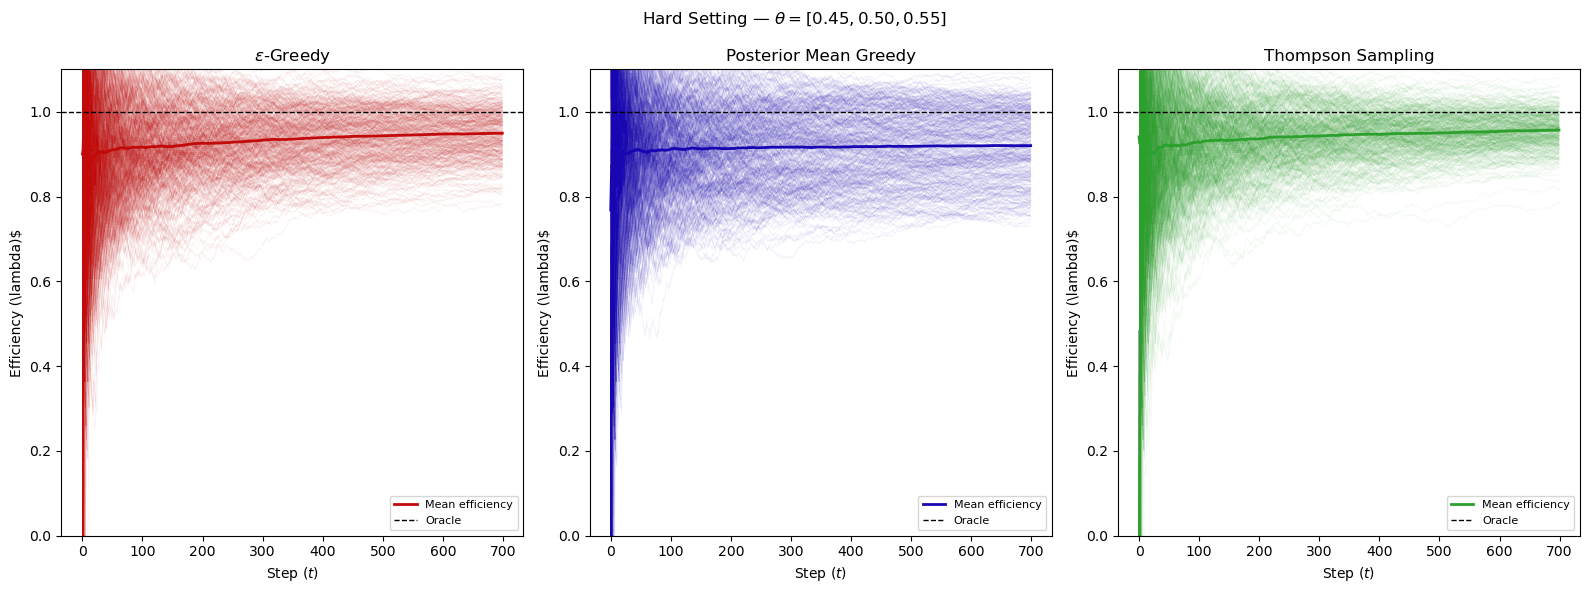

In [31]:
# Params
T, n_paths = 700, 400
theta = [0.45, 0.50, 0.55]
K = len(theta)

# Oracle
mu_star = max(theta)
oracle = np.arange(1, T + 1) * mu_star

# MC Simulation
rw_eps, _ = monte_carlo(epsilon_greedy, n_paths, T, K, theta)
rw_pmg, _ = monte_carlo(posterior_mean_greedy, n_paths, T, K, theta)
rw_ts, _ = monte_carlo(thompson_sampling, n_paths, T, K, theta)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, rw, color, label in zip(axes, [rw_eps, rw_pmg, rw_ts], colors, strategies):
    cum = rw.cumsum(axis=1)
    eff = cum / oracle
    for path in eff:
        ax.plot(path, alpha=0.06, linewidth=0.6, color=color)
    ax.plot(eff.mean(axis=0), color=color, linewidth=2, label="Mean efficiency")
    ax.axhline(1.0, color="black", linewidth=1, linestyle="--", label="Oracle")
    ax.set_ylim(0, 1.1)
    ax.set_title(label)
    ax.set_xlabel("Step ($t$)")
    ax.set_ylabel(r"Efficiency (\lambda)$")
    ax.legend(fontsize=8)

plt.suptitle(r"Hard Setting — $\theta = [0.45, 0.50, 0.55]$", fontsize=12)
plt.tight_layout()
plt.show()

In the hard setting, the small gaps make discrimination difficult — all three strategies show higher dispersion than in the easy case. $\varepsilon$-Greedy appears stable but plateaus around 0.94. Posterior Mean Greedy shows the widest band — small gaps amplify lock-in risk, and many paths remain trapped on a suboptimal arm well past $t = 500$. Thompson Sampling carries less per-path variance than $\varepsilon$-Greedy, but does not have a strong edge.

#### &nbsp;&nbsp; 9.3. Misleading Start

This third situation presents three arms with high reward probability $\theta = [0.7, 0.75, 0.4, 0.3, 0.8]$. The trap is that arm 1 is strong but not optimal. This creates a natural early trap for strategies that commit too quickly and do not update efficiently.

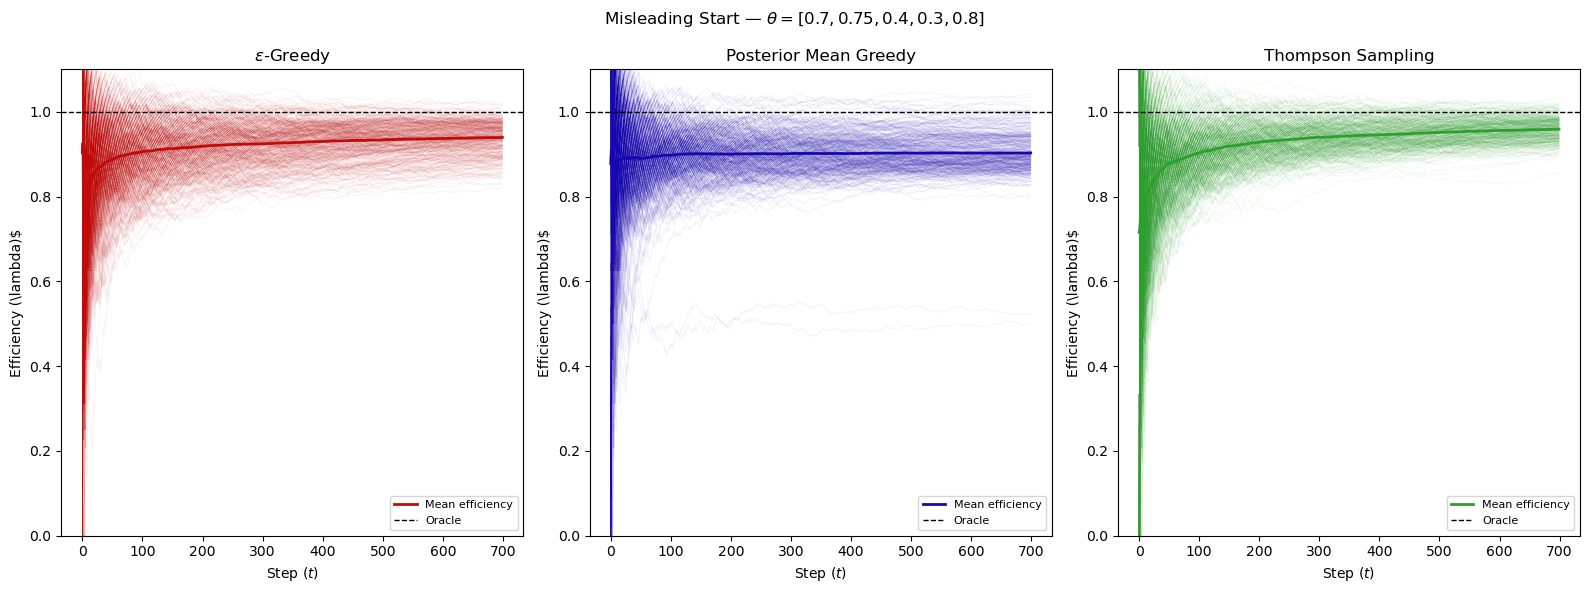

In [32]:
# Prams
T, n_paths = 700, 400
theta = [0.7, 0.75, 0.4, 0.3, 0.8]
K = len(theta)

# Oracle
mu_star = max(theta)
oracle = np.arange(1, T + 1) * mu_star

# MC Simulation
rw_eps, _ = monte_carlo(epsilon_greedy, n_paths, T, K, theta)
rw_pmg, _ = monte_carlo(posterior_mean_greedy, n_paths, T, K, theta)
rw_ts, _ = monte_carlo(thompson_sampling, n_paths, T, K, theta)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, rw, color, label in zip(axes, [rw_eps, rw_pmg, rw_ts], colors, strategies):
    cum = rw.cumsum(axis=1)
    eff = cum / oracle
    for path in eff:
        ax.plot(path, alpha=0.06, linewidth=0.6, color=color)
    ax.plot(eff.mean(axis=0), color=color, linewidth=2, label="Mean efficiency")
    ax.axhline(1.0, color="black", linewidth=1, linestyle="--", label="Oracle")
    ax.set_ylim(0, 1.1)
    ax.set_title(label)
    ax.set_xlabel("Step ($t$)")
    ax.set_ylabel(r"Efficiency (\lambda)$")
    ax.legend(fontsize=8)

plt.suptitle(r"Misleading Start — $\theta = [0.7, 0.75, 0.4, 0.3, 0.8]$", fontsize=12)
plt.tight_layout()
plt.show()

The misleading start scenario is the most revealing so far. Arms 1 and 2 are strong ($\theta = 0.7, 0.75$) but not optimal as they create an early pull away from the true best arm. Posterior Mean Greedy is the most exposed: many paths lock in on arm 1 or 2 early and never recover. Thompson Sampling corrects naturally: as arm 5 accumulates observations its posterior sharpens above the competitors, and the mean trajectory continues climbing toward 1 with a tight band by $t = 400$.

#### &nbsp;&nbsp; 9.4. Many Arms

The last scenario is the most realistic. It presents 10 arms drawn uniformly from $[0.2, 0.9]$. In a practical setting, the exploration cost scales with $K$. This scenario tests how each strategy handles a large action space where most arms are suboptimal.

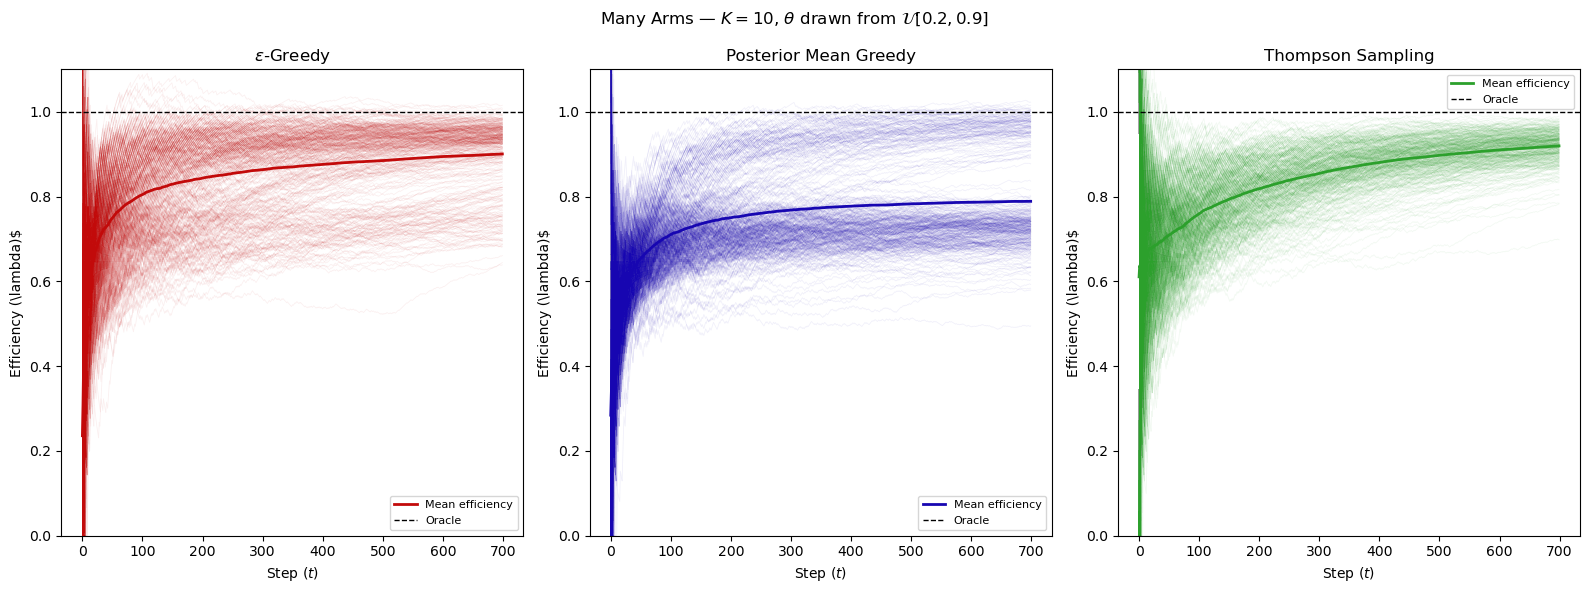

In [35]:
# Params
T, n_paths = 700, 400
theta = sorted(np.random.uniform(0.2, 0.9, 10).tolist())
K = len(theta)

# Oracle
mu_star = max(theta)
oracle = np.arange(1, T + 1) * mu_star

# MC Simulation
rw_eps, _ = monte_carlo(epsilon_greedy, n_paths, T, K, theta)
rw_pmg, _ = monte_carlo(posterior_mean_greedy, n_paths, T, K, theta)
rw_ts, _ = monte_carlo(thompson_sampling, n_paths, T, K, theta)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, rw, color, label in zip(axes, [rw_eps, rw_pmg, rw_ts], colors, strategies):
    cum = rw.cumsum(axis=1)
    eff = cum / oracle
    for path in eff:
        ax.plot(path, alpha=0.06, linewidth=0.6, color=color)
    ax.plot(eff.mean(axis=0), color=color, linewidth=2, label="Mean efficiency")
    ax.axhline(1.0, color="black", linewidth=1, linestyle="--", label="Oracle")
    ax.set_ylim(0, 1.1)
    ax.set_title(label)
    ax.set_xlabel("Step ($t$)")
    ax.set_ylabel(r"Efficiency (\lambda)$")
    ax.legend(fontsize=8)

plt.suptitle(f"Many Arms — $K=10$, $\\theta$ drawn from $\\mathcal{{U}}[0.2, 0.9]$", fontsize=12)
plt.tight_layout()
plt.show()

With $K = 10$ arms, the exploration cost scales dramatically. $\varepsilon$-Greedy spreads its random pulls across all ten arms — it converges slowly, reaching only 0.90 by $t = 700$, and never closes the gap to the oracle. Posterior Mean Greedy is the most exposed: with many arms to initialize, early noise has more opportunities to create lock-in, and the mean plateaus around 0.75 — the worst performance across all scenarios. 

Thompson Sampling scales gracefully: arms that are clearly suboptimal quickly develop low posteriors and stop being sampled, naturally concentrating exploration on the competitive arms. Its mean reaches 0.95 by $t = 700$ with the tightest band of the three, by far.

### 10. Conclusion

This notebook illustrates how optimal decision rules emerge progressively once uncertainty is treated as a structural component of the optimization problem, rather than a nuisance to be averaged away.

We show that:

- pure exploitation and uniform exploration both accumulate linear regret — learning and optimizing are in fundamental conflict,
- $\varepsilon$-Greedy resolves the tension mechanically but explores blindly, permanently sacrificing a fixed fraction of pulls even after the best arm is identified,
- the Bayesian framework provides a natural language for uncertainty — belief states summarize everything the agent knows, and update cleanly with each observation,
- posterior mean greedy improves over frequentist estimates but remains myopic — it acts on what it knows without valuing what it could learn,
- Thompson Sampling integrates learning and optimization into a single rule, allocating exploration proportionally to uncertainty and phasing it out as beliefs sharpen,
- the exact optimal policy requires solving a dynamic program over the belief space, which is computationally intractable — Thompson Sampling is its best tractable approximation.

Overall, optimal sequential decision-making requires treating uncertainty not as noise to eliminate, but as information to act on.